In [1]:
import os
import pandas as pd
import numpy as np
from tqdm import tqdm
import matplotlib.pyplot as plt
from datetime import datetime
import seaborn as sns
import pickle as pkl
import math
import glob
import re
sns.set(style='whitegrid')

In [2]:
results_val = {}
results_tr = {}

In [ ]:
def grab_data(wid_exp, lrs, seeds, time, depth, act = lambda x: x // 4): #operates on results_val and results_tr in place
    for lr in lrs:
        for width, num_exp, _ in wid_exp:
                num_act = act(num_exp)
                for seed in seeds:
                    print()
                    file_name = f'../run_data/mutransfer_lr_cccc/out_{time}/width{width}_depth{depth}_experts{num_exp}_active{num_act}_seed{seed}_lr{lr}_alpha1.0_mult0.5/log.csv'
                    if os.path.exists(file_name):
                        try:
                            csv_df = pd.read_csv(file_name)
                        except:
                            print(f"File {file_name} is corrupted, skipping")
                            results_val[(width, num_exp, num_act, seed, lr)] = 10.0
                            results_tr[(width, num_exp, num_act, seed, lr)] = 10.0
                            continue
                        val_loss = csv_df.iloc[-1]['val/loss']
                        if val_loss > 0.0:
                            avg_train_loss = np.mean(csv_df['train/loss'][-50:])
                            print(f"result found for {file_name}, val_loss achieved {val_loss}")
                            print(f"average training loss for last 50 steps: {avg_train_loss}")
                            results_val[(width, num_exp, num_act, seed, lr)] = val_loss
                            results_tr[(width, num_exp, num_act, seed, lr)] = avg_train_loss
                        else:
                            print(f"No validation loss found for {file_name}, trial ended at iteration {csv_df.shape[0]}")
                            print(f"Lowest traininig loss achieved: {np.min(csv_df['train/loss'])}")
                    else:
                        print(f"File {file_name} does not exist, check your path")

def max_deviation_last_checkpoint(filename):
    '''
    max_deviation_last_checkpoint("/home/ubuntu/MuP_MOE/std_out/mutransfer_lr_cccc/20251016_025824/stdout/job_0003_gpu3_w768_exp48_lr4.00e-03_seed1_alpha1.0_mult0.5.log") 
    0.016
    '''
    with open(filename, "r", encoding="utf-8", errors="ignore") as f:
        text = f.read()
    matches = list(re.finditer(r"Validation - step\s+\d+", text))
    if not matches:
        raise ValueError("No 'Validation - step' found in file.")
    start_idx = matches[-1].start()
    tail = text[start_idx:]
    deviations = re.findall(
        r"^L\d+:[^\n]*?max_deviation=([0-9]+(?:\.[0-9]+)?)",
        tail,
        flags=re.M
    )
    if not deviations:
        raise ValueError("No 'max_deviation' entries found after last checkpoint.")
    return max(map(float, deviations))

def plot_results(result, title = ""):
    plt.figure(figsize=(10, 6))
    config_results = {}
    for (width, num_exp, num_act, seed, lr), mse in result.items():
        config = (num_exp, num_act, width)
        if config not in config_results:
            config_results[config] = []
        config_results[config].append((lr, mse))
    averaged_results = {}
    for config, pts in config_results.items():
        lr_to_mses = {}
        for lr, mse in pts:
            if lr not in lr_to_mses:
                lr_to_mses[lr] = []
            lr_to_mses[lr].append(mse)
        averaged_pts = []
        for lr in sorted(lr_to_mses.keys()):
            avg_mse = np.mean(lr_to_mses[lr])
            averaged_pts.append((lr, avg_mse))
        averaged_results[config] = averaged_pts
    total_experiments = len(result)
    print(f"Total experiments: {total_experiments}")
    print("\nResults by configuration:")
    for (n_exp, num_act, width), pts in sorted(averaged_results.items()):
        valid_pts = [(lr, mse) for lr, mse in pts if not math.isnan(mse)]
        print(f"  n={n_exp}, n_act={num_act}, width={width}: {len(valid_pts)} valid lr points")
        if valid_pts:
            best_lr, best_mse = min(valid_pts, key=lambda x: x[1])
            print(f"    Best: lr={best_lr:.3e}, MSE={best_mse:.6f}")
    colors = plt.cm.tab10(np.linspace(0, 1, 10))
    markers = ['o', 's', '^', 'v', 'D', 'p', '*', 'h']
    
    for idx, ((n_exp, num_act ,width), pts) in enumerate(sorted(averaged_results.items())):
        if pts:
            # Sort by lr for proper line plotting
            pts_sorted = sorted(pts, key=lambda t: t[0])
            lrs_plot, mses = zip(*pts_sorted)
            
            # Filter out NaN values
            valid_pts = [(lr, mse) for lr, mse in zip(lrs_plot, mses) if not math.isnan(mse)]
            
            if valid_pts:
                valid_lrs, valid_mses = zip(*valid_pts)
                color = colors[idx % len(colors)]
                marker = markers[idx % len(markers)]
                plt.plot(valid_lrs, valid_mses, marker=marker, color=color,
                        label=f'n_exp={n_exp}, n_act={num_act}, width={width}', linewidth=1.5, markersize=6,
                        alpha=0.8)
                
                # Mark the best point with a star
                best_idx = np.argmin(valid_mses)
                plt.scatter(valid_lrs[best_idx], valid_mses[best_idx], 
                           s=200, color=color, marker='*', edgecolor='black', 
                           linewidth=2, zorder=10)

    plt.xscale('log', base=2)
    plt.yscale('log')
    plt.ylim(3.1, 4.1)
    plt.xlabel(r'Learning rate', fontsize=12)
    plt.ylabel('log perplexity', fontsize=12)
    plt.title(f'Hyperparameter Transfer Results ' + title, 
              fontsize=14)
    plt.legend(fontsize=10, loc='best', ncol=2)
    plt.grid(True, alpha=0.3, which='both')
    plt.tight_layout()
    
    # Save plot
    plot_dir = "plots"
    os.makedirs(plot_dir, exist_ok=True)
    timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
    plot_name = os.path.join(plot_dir, f"hp_transfer_plot_5kit_{timestamp}.png")
    plt.savefig(plot_name, dpi=150, bbox_inches='tight')
    print(f"\nPlot saved as: {plot_name}")
    plt.show()
    return averaged_results

def get_filenames_in_dir(directory_path):
    '''
    get_filenames_in_dir("/home/ubuntu/MuP_MOE/std_out/mutransfer_lr_cccc/"+time+"/stdout")
    ['job_0007_gpu7_w384_exp64_lr6.40e-02_seed1_alpha1.0_mult0.0.log',
    'job_0002_gpu2_w384_exp64_lr2.00e-03_seed1_alpha1.0_mult0.0.log',
    'job_0000_gpu0_w384_exp64_lr5.00e-04_seed1_alpha1.0_mult0.0.log',
    'job_0005_gpu5_w384_exp64_lr1.60e-02_seed1_alpha1.0_mult0.0.log',
    'job_0006_gpu6_w384_exp64_lr3.20e-02_seed1_alpha1.0_mult0.0.log',
    'job_0004_gpu4_w384_exp64_lr8.00e-03_seed1_alpha1.0_mult0.0.log',
    'job_0003_gpu3_w384_exp64_lr4.00e-03_seed1_alpha1.0_mult0.0.log',
    'job_0001_gpu1_w384_exp64_lr1.00e-03_seed1_alpha1.0_mult0.0.log']
    '''
    try:
        filenames = os.listdir(directory_path)
        return filenames
    except FileNotFoundError:
        print(f"Directory not found: {directory_path}")
        return []

def find_job_file(base_path, time_dir, job_prefix):
    '''
    find_job_file("/home/ubuntu/MuP_MOE/std_out/mutransfer_lr_cccc/", '20251015_032643', 'job_0007_gpu7_w384_exp64_lr6.40e-02_seed1_alpha1.0_mult0.0.log') 
    ('job_0007_gpu7_w384_exp64_lr6.40e-02_seed1_alpha1.0_mult0.0.log',
    {'width': 384,
    'num_exp': 64,
    'lr': 0.064,
    'seed': 1,
    'alpha': 1.0,
    'mult': 0.0})
    '''
    search_pattern = os.path.join(base_path, time_dir, "stdout", f"{job_prefix}")
    matches = glob.glob(search_pattern)
    if not matches:
        return None, None
    full_path = matches[0]
    filename = os.path.basename(full_path)
    pattern = r'job_\d+_gpu\d+_w(\d+)_exp(\d+)_lr([\d.e\-+]+)_seed(\d+)_alpha([\d.]+)_mult([\d.]+)\.log'
    match = re.match(pattern, filename)
    if not match:
        return filename, None
    params = {
                       'width': int(match.group(1)),
                       'num_exp': int(match.group(2)),
                       'lr': float(match.group(3)),
                       'seed': int(match.group(4)),
                       'alpha': float(match.group(5)),
                       'mult': float(match.group(6))
            }
    return filename, params

def parse_validation_loss(log_file_path): 
    '''
    result = parse_validation_loss("/home/ubuntu/MuP_MOE/std_out/mutransfer_lr_cccc/20250930_041850/stdout/job_0006_gpu6_w512_exp4_lr2.00e-03_seed3.log")
    {1: 10.8439, 1001: 5.4033, 2001: 4.6293, 3001: 4.3399, 4001: 4.1837, 5001: 4.0975, 6001: 4.0193, 7001: 3.965, 8001: 3.9159, 9001: 3.8888, 10001: 3.884}
    '''
    result = {}
    pattern = r'Validation - step (\d+): val loss ([\d.]+)'

    try:
        with open(log_file_path, 'r') as f:
            for line in f:
                match = re.search(pattern, line)
                if match:
                    step = int(match.group(1))
                    loss = float(match.group(2))
                    result[step] = loss
    except FileNotFoundError:
        print(f"Error: File {log_file_path} not found")
        return {}
    except Exception as e:
        print(f"Error reading file: {e}")
        return {}
    return result

In [4]:
wid_exp = [(512, 4, 220), (768, 4, 0), (1024, 4, 0), (512, 8, 350), (768, 8, 0), (512, 16, 0), (768, 16, 650)]
lrs = [0.001, 0.002, 0.004, 0.008, 0.016, 0.032, 0.064, 0.128,]
seeds = [1]
depth = 14
time = '20251013_024706'
grab_data(wid_exp, lrs, seeds, time, depth)


result found for ../run_data/mutransfer_lr_cccc/out_20251013_024706/width512_depth14_experts4_active1_seed1_lr0.001_alpha1.0_mult0.5/log.csv, val_loss achieved 3.7865936756134033
average training loss for last 50 steps: 3.783496618270874

result found for ../run_data/mutransfer_lr_cccc/out_20251013_024706/width768_depth14_experts4_active1_seed1_lr0.001_alpha1.0_mult0.5/log.csv, val_loss achieved 3.6576874256134033
average training loss for last 50 steps: 3.6604092121124263

result found for ../run_data/mutransfer_lr_cccc/out_20251013_024706/width1024_depth14_experts4_active1_seed1_lr0.001_alpha1.0_mult0.5/log.csv, val_loss achieved 3.630104541778565
average training loss for last 50 steps: 3.621747493743897

result found for ../run_data/mutransfer_lr_cccc/out_20251013_024706/width512_depth14_experts8_active2_seed1_lr0.001_alpha1.0_mult0.5/log.csv, val_loss achieved 3.6861400604248047
average training loss for last 50 steps: 3.684504508972168

result found for ../run_data/mutransfer_lr

In [5]:
wid_exp = [(384, 64, 220)]
lrs = [0.0005, 0.001, 0.002, 0.004, 0.008, 0.016, 0.032, 0.064, ]
seeds = [1]
depth = 14
time = '20251014_041549'
grab_data(wid_exp, lrs, seeds, time, depth)


result found for ../run_data/mutransfer_lr_cccc/out_20251014_041549/width384_depth14_experts64_active16_seed1_lr0.0005_alpha1.0_mult0.5/log.csv, val_loss achieved 3.626338005065918
average training loss for last 50 steps: 3.6234519481658936

result found for ../run_data/mutransfer_lr_cccc/out_20251014_041549/width384_depth14_experts64_active16_seed1_lr0.001_alpha1.0_mult0.5/log.csv, val_loss achieved 3.5388898849487305
average training loss for last 50 steps: 3.5354039669036865

result found for ../run_data/mutransfer_lr_cccc/out_20251014_041549/width384_depth14_experts64_active16_seed1_lr0.002_alpha1.0_mult0.5/log.csv, val_loss achieved 3.4713151454925537
average training loss for last 50 steps: 3.4675300121307373

result found for ../run_data/mutransfer_lr_cccc/out_20251014_041549/width384_depth14_experts64_active16_seed1_lr0.004_alpha1.0_mult0.5/log.csv, val_loss achieved 3.444397449493408
average training loss for last 50 steps: 3.440614461898804

result found for ../run_data/mutr

In [6]:
wid_exp = [(384, 16, 220)]
lrs = [0.0005, 0.001, 0.002, 0.004, 0.008, 0.016, 0.032, 0.064, ]
seeds = [1]
depth = 14
time = '20251014_212347'
grab_data(wid_exp, lrs, seeds, time, depth)


result found for ../run_data/mutransfer_lr_cccc/out_20251014_212347/width384_depth14_experts16_active4_seed1_lr0.0005_alpha1.0_mult0.5/log.csv, val_loss achieved 3.810916185379028
average training loss for last 50 steps: 3.810624122619629

result found for ../run_data/mutransfer_lr_cccc/out_20251014_212347/width384_depth14_experts16_active4_seed1_lr0.001_alpha1.0_mult0.5/log.csv, val_loss achieved 3.6910340785980233
average training loss for last 50 steps: 3.691205501556397

result found for ../run_data/mutransfer_lr_cccc/out_20251014_212347/width384_depth14_experts16_active4_seed1_lr0.002_alpha1.0_mult0.5/log.csv, val_loss achieved 3.619148969650269
average training loss for last 50 steps: 3.6192338466644287

result found for ../run_data/mutransfer_lr_cccc/out_20251014_212347/width384_depth14_experts16_active4_seed1_lr0.004_alpha1.0_mult0.5/log.csv, val_loss achieved 3.58491849899292
average training loss for last 50 steps: 3.584678173065185

result found for ../run_data/mutransfer_l

In [7]:
wid_exp = [(768, 16, 220)]
lrs = [0.0005, 0.001, 0.002, 0.004, 0.008, 0.016, 0.032, 0.064, ]
seeds = [1]
depth = 14
time = '20251015_030709'
grab_data(wid_exp, lrs, seeds, time, depth)


result found for ../run_data/mutransfer_lr_cccc/out_20251015_030709/width768_depth14_experts16_active4_seed1_lr0.0005_alpha1.0_mult0.5/log.csv, val_loss achieved 3.6281349658966064
average training loss for last 50 steps: 3.622272729873657

result found for ../run_data/mutransfer_lr_cccc/out_20251015_030709/width768_depth14_experts16_active4_seed1_lr0.001_alpha1.0_mult0.5/log.csv, val_loss achieved 3.520471572875977
average training loss for last 50 steps: 3.514117956161499

result found for ../run_data/mutransfer_lr_cccc/out_20251015_030709/width768_depth14_experts16_active4_seed1_lr0.002_alpha1.0_mult0.5/log.csv, val_loss achieved 3.4183638095855717
average training loss for last 50 steps: 3.411499261856079

result found for ../run_data/mutransfer_lr_cccc/out_20251015_030709/width768_depth14_experts16_active4_seed1_lr0.004_alpha1.0_mult0.5/log.csv, val_loss achieved 3.395834922790528
average training loss for last 50 steps: 3.389042615890503

result found for ../run_data/mutransfer_

In [8]:
wid_exp = [(768, 16, 220)]
lrs = [0.0005, 0.001, 0.002, 0.004, 0.008, 0.016, 0.032, 0.064, ]
seeds = [1]
depth = 14
time = '20251015_030709'
grab_data(wid_exp, lrs, seeds, time, depth)


result found for ../run_data/mutransfer_lr_cccc/out_20251015_030709/width768_depth14_experts16_active4_seed1_lr0.0005_alpha1.0_mult0.5/log.csv, val_loss achieved 3.6281349658966064
average training loss for last 50 steps: 3.622272729873657

result found for ../run_data/mutransfer_lr_cccc/out_20251015_030709/width768_depth14_experts16_active4_seed1_lr0.001_alpha1.0_mult0.5/log.csv, val_loss achieved 3.520471572875977
average training loss for last 50 steps: 3.514117956161499

result found for ../run_data/mutransfer_lr_cccc/out_20251015_030709/width768_depth14_experts16_active4_seed1_lr0.002_alpha1.0_mult0.5/log.csv, val_loss achieved 3.4183638095855717
average training loss for last 50 steps: 3.411499261856079

result found for ../run_data/mutransfer_lr_cccc/out_20251015_030709/width768_depth14_experts16_active4_seed1_lr0.004_alpha1.0_mult0.5/log.csv, val_loss achieved 3.395834922790528
average training loss for last 50 steps: 3.389042615890503

result found for ../run_data/mutransfer_

In [9]:
wid_exp = [(384, 64, 220)]
lrs = [0.0005, 0.001, 0.002, 0.004, 0.008, 0.016, 0.032, 0.064, ]
seeds = [1]
depth = 14
time = '20251015_032643'
### No router learning ###
for lr in lrs:
    for width, num_exp, _ in wid_exp:
            num_act = int(num_exp // 4)
            for seed in seeds:
                print()
                file_name = f'../run_data/mutransfer_lr_cccc/out_{time}/width{width}_depth{depth}_experts{num_exp}_active{num_act}_seed{seed}_lr{lr}_alpha1.0_mult0.0/log.csv'
                if os.path.exists(file_name):
                    try:
                        csv_df = pd.read_csv(file_name)
                    except:
                        print(f"File {file_name} is corrupted, skipping")
                        results_val[(width, num_exp, 0, seed, lr)] = 10.0
                        results_tr[(width, num_exp, 0, seed, lr)] = 10.0
                        continue
                    val_loss = csv_df.iloc[-1]['val/loss']
                    if val_loss > 0.0:
                        avg_train_loss = np.mean(csv_df['train/loss'][-50:])
                        print(f"result found for {file_name}, val_loss achieved {val_loss}")
                        print(f"average training loss for last 50 steps: {avg_train_loss}")
                        results_val[(width, num_exp, 0, seed, lr)] = val_loss
                        results_tr[(width, num_exp, 0, seed, lr)] = avg_train_loss
                    else:
                        print(f"No validation loss found for {file_name}, trial ended at iteration {csv_df.shape[0]}")
                        print(f"Lowest traininig loss achieved: {np.min(csv_df['train/loss'])}")
                else:
                    print(f"File {file_name} does not exist, check your path")


result found for ../run_data/mutransfer_lr_cccc/out_20251015_032643/width384_depth14_experts64_active16_seed1_lr0.0005_alpha1.0_mult0.0/log.csv, val_loss achieved 3.646726608276367
average training loss for last 50 steps: 3.643865585327149

result found for ../run_data/mutransfer_lr_cccc/out_20251015_032643/width384_depth14_experts64_active16_seed1_lr0.001_alpha1.0_mult0.0/log.csv, val_loss achieved 3.5682339668273926
average training loss for last 50 steps: 3.564723491668701

result found for ../run_data/mutransfer_lr_cccc/out_20251015_032643/width384_depth14_experts64_active16_seed1_lr0.002_alpha1.0_mult0.0/log.csv, val_loss achieved 3.501498222351074
average training loss for last 50 steps: 3.498119115829468

result found for ../run_data/mutransfer_lr_cccc/out_20251015_032643/width384_depth14_experts64_active16_seed1_lr0.004_alpha1.0_mult0.0/log.csv, val_loss achieved 3.477026462554932
average training loss for last 50 steps: 3.4734888076782227

result found for ../run_data/mutrans

In [10]:
results_val[(384, 16, 16, 1, 0.0005)] = 3.9598388671875
results_val[(384, 16, 16, 1, 0.001)] = 3.750851631164551
results_val[(384, 16, 16, 1, 0.002)] = 3.589658737182617
results_val[(384, 16, 16, 1, 0.004)] = 3.5156939029693604
results_val[(384, 16, 16, 1, 0.008)] = 3.489361047744751
results_val[(384, 16, 16, 1, 0.016)] = 3.5982751846313477
results_val[(384, 16, 16, 1, 0.032)] = 3.655024528503418
results_val[(384, 16, 16, 1, 0.064)] = 3.960522174835205

Total experiments: 80

Results by configuration:
  n=4, n_act=1, width=512: 8 valid lr points
    Best: lr=2.000e-03, MSE=3.690140
  n=4, n_act=1, width=768: 8 valid lr points
    Best: lr=8.000e-03, MSE=3.557806
  n=4, n_act=1, width=1024: 8 valid lr points
    Best: lr=8.000e-03, MSE=3.495493
  n=8, n_act=2, width=512: 8 valid lr points
    Best: lr=4.000e-03, MSE=3.571536
  n=8, n_act=2, width=768: 8 valid lr points
    Best: lr=4.000e-03, MSE=3.454542
  n=16, n_act=4, width=384: 8 valid lr points
    Best: lr=8.000e-03, MSE=3.575803
  n=16, n_act=4, width=768: 8 valid lr points
    Best: lr=8.000e-03, MSE=3.390468
  n=16, n_act=16, width=384: 8 valid lr points
    Best: lr=8.000e-03, MSE=3.489361
  n=64, n_act=0, width=384: 8 valid lr points
    Best: lr=8.000e-03, MSE=3.466054
  n=64, n_act=16, width=384: 8 valid lr points
    Best: lr=8.000e-03, MSE=3.424597



Plot saved as: plots/hp_transfer_plot_20251017_181130.png


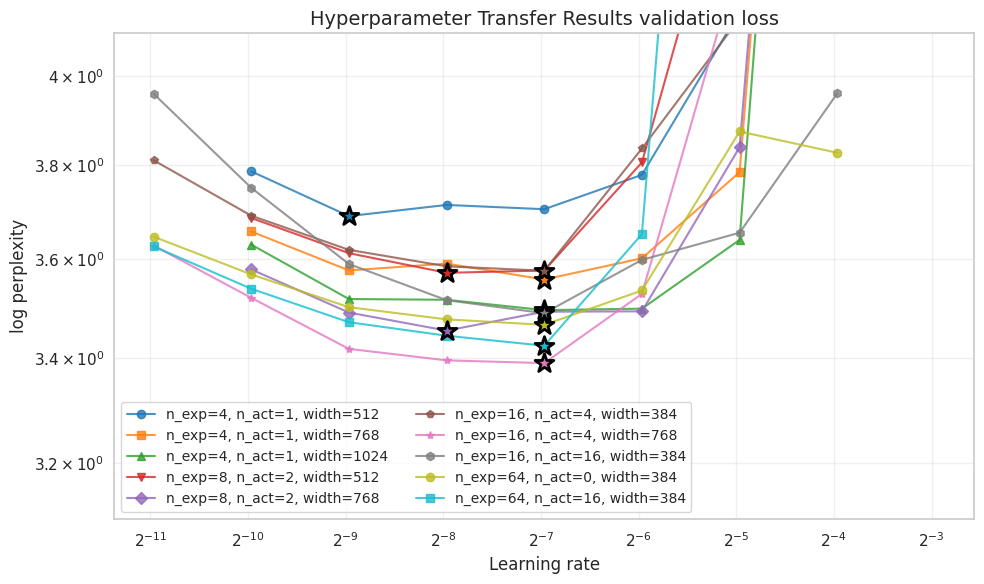

{(4, 1, 512): [(0.001, np.float64(3.7865936756134033)),
  (0.002, np.float64(3.690140008926392)),
  (0.004, np.float64(3.7140302658081055)),
  (0.008, np.float64(3.7048845291137695)),
  (0.016, np.float64(3.778902053833008)),
  (0.032, np.float64(4.151767253875732)),
  (0.064, np.float64(7.583602428436279)),
  (0.128, np.float64(7.649203777313232))],
 (4, 1, 768): [(0.001, np.float64(3.6576874256134033)),
  (0.002, np.float64(3.5764636993408203)),
  (0.004, np.float64(3.590517997741699)),
  (0.008, np.float64(3.5578062534332275)),
  (0.016, np.float64(3.6015470027923584)),
  (0.032, np.float64(3.784698724746704)),
  (0.064, np.float64(7.572890281677246)),
  (0.128, np.float64(7.64145040512085))],
 (4, 1, 1024): [(0.001, np.float64(3.630104541778565)),
  (0.002, np.float64(3.517993211746216)),
  (0.004, np.float64(3.5164883136749268)),
  (0.008, np.float64(3.4954934120178223)),
  (0.016, np.float64(3.498582601547241)),
  (0.032, np.float64(3.6398985385894775)),
  (0.064, np.float64(7.59

In [11]:
plot_results(results_val, title = "validation loss")